# Chapter 4: Density-Based Clustering

This notebook accompanies **Chapter 4** of the lecture notes.

**Agenda**

☕ · 🔍 · 📌 · 📈 · 🆚 · 🏁

**Next steps (take it from here):** 🏗️ · 🌀 · 🔬

> **Tip:** Run cells top to bottom. Later cells depend on earlier ones.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.spatial.distance import cdist
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.cluster.vq import kmeans2
import sys; sys.path.insert(0, '../..')
from plot_style import *
from checks import (
    check_epsilon_neighbors, check_core_mask,
    check_k_distances, check_dbscan,
    check_count_clusters, check_mutual_reachability,
)

## ☕ The Aroma Dataset

In Chapter 3 you built hierarchical clusterings of 1 797 coffee aroma fingerprints and cut the dendrogram at various heights. Ward linkage agreed well with K-Means, but both methods carved the data into compact, roughly spherical regions. What if the natural clusters are not spherical at all?

Density-based clustering takes a different view: a cluster is a region where points are **densely packed**, separated from other clusters by regions of **low density**. The algorithm needs no cluster count K. It discovers clusters of arbitrary shape and automatically labels sparse outliers as **noise**.

> Look at the scatter below. Some varieties form tight, round islands, others form elongated bands that wrap around neighbors. Which groups would a spherical method like K-Means split incorrectly, and which would survive intact?

<details><summary>Thought</summary>

The milk-based varieties (latte, flat white, cappuccino) overlap in an extended, crescent-shaped region that K-Means would bisect with a straight boundary. Cold brew and pour over form a loose arc along the left edge rather than a compact ball. Espresso and ristretto, however, sit in tight round clusters that any method would recover. Density-based clustering should trace the actual shape of each cloud rather than forcing a Voronoi partition.
</details>

1797 samples, 10 varieties


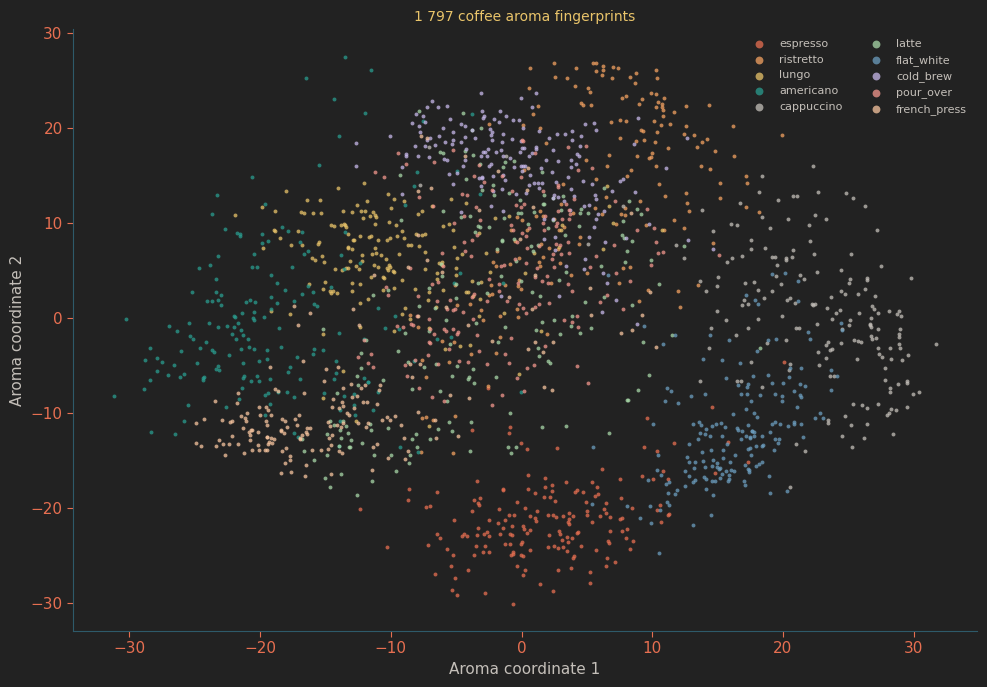

In [2]:
df     = pd.read_csv('coffee_aroma_2d.csv')
X      = df[['x1', 'x2']].values
labels = df['variety'].values
n      = len(X)
print(f'{n} samples, {len(np.unique(labels))} varieties')

fig, ax = plt.subplots(figsize=(10, 7))
for variety, color in _variety_colors.items():
    mask = labels == variety
    ax.scatter(X[mask, 0], X[mask, 1],
               c=color, s=8, linewidths=0, label=variety, alpha=0.75)

ax.set_xlabel('Aroma coordinate 1')
ax.set_ylabel('Aroma coordinate 2')
ax.set_title('1 797 coffee aroma fingerprints', fontsize=10)
ax.legend(ncol=2, frameon=False, fontsize=8, markerscale=2, labelcolor=_TEXT)
tufte_axis(ax)
plt.tight_layout()
plt.show()

**Observe:**
- Espresso and ristretto form compact islands in the lower-right.
- Milk-based drinks (latte, flat white, cappuccino) overlap in an extended region in the upper-left.
- Cold brew, pour over, and french press spread along the left edge.
- Americano and lungo sit between the concentrated and slow-extraction groups.

## 🔍 Epsilon-Neighborhoods

The building block of DBSCAN is the **epsilon-neighborhood**: the set of all points within distance eps of a given point, including the point itself.

> If you draw a circle of radius eps around an espresso sample in the dense core of that cluster, you might capture 20 neighbors. The same circle around an americano sample at the fringe of two groups might capture only 3. What does this difference in local density tell you about how confident you should be that each point belongs to a cluster?

<details><summary>Thought</summary>

A point surrounded by many neighbors within eps sits in a genuinely dense region and is almost certainly part of a cluster. A point with very few neighbors could be on the boundary between clusters, in a sparse transition zone, or an outlier entirely. DBSCAN formalizes this intuition with a threshold called min_samples: only points with enough neighbors qualify as cluster seeds. Points with fewer neighbors are either absorbed as border points or discarded as noise.
</details>

Implement `epsilon_neighbors`: return a **sorted array of indices** of all points within distance eps of `X[point_idx]` (including `point_idx` itself).

Useful operations: `np.sqrt()`, `np.sum(..., axis=1)`, `np.where()`, `np.sort()`.

In [3]:
def epsilon_neighbors(point_idx, X, eps):
    """Return sorted array of indices within eps of X[point_idx] (including self)."""
    # YOUR CODE HERE
    pass


check_epsilon_neighbors(epsilon_neighbors, 0, X, 3.0)

  ⬜ epsilon_neighbors: not implemented yet (expected 34 neighbors)


In [4]:
# Visualize the epsilon-neighborhood of a sample point
_test_idx = 0
_test_eps = 3.0
_nbrs = epsilon_neighbors(_test_idx, X, _test_eps)

if _nbrs is None:
    print('\u2b1c Implement epsilon_neighbors above first.')
else:
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.scatter(X[:, 0], X[:, 1], c=_BORDER, s=6, linewidths=0, alpha=0.3)
    ax.scatter(X[_nbrs, 0], X[_nbrs, 1], c=_ACCENT, s=15, linewidths=0,
               label=f'{len(_nbrs)} neighbors', zorder=3)
    ax.scatter(X[_test_idx, 0], X[_test_idx, 1], c=_TERRA, s=60,
               linewidths=0, marker='*', label=f'Sample {_test_idx}', zorder=4)
    circle = plt.Circle(X[_test_idx], _test_eps, fill=False,
                        edgecolor=_GOLDEN, linewidth=1.2, linestyle='--')
    ax.add_patch(circle)
    ax.set_xlabel('Aroma coordinate 1')
    ax.set_ylabel('Aroma coordinate 2')
    ax.set_title(f'eps = {_test_eps} neighborhood of sample {_test_idx} ({labels[_test_idx]})', fontsize=10)
    ax.set_aspect('equal')
    ax.legend(frameon=False, fontsize=9, labelcolor=_TEXT)
    tufte_axis(ax)
    plt.tight_layout()
    plt.show()

⬜ Implement epsilon_neighbors above first.


## 📌 Core, Border, and Noise

DBSCAN classifies every point into one of three types:

- **Core point:** has at least `min_samples` points in its eps-neighborhood (including itself).
- **Border point:** not core, but within eps of at least one core point.
- **Noise point:** neither core nor within eps of any core point.

The first step is identifying which points are core.

> With eps = 2.0 and min_samples = 10, most espresso samples sit in a dense ball and will be core points. What about the americano samples scattered between groups — do you expect them to be core, border, or noise?

<details><summary>Thought</summary>

Americano samples live in a transition zone between the concentrated and slow-extraction regions. Their local density depends on whether enough neighbors from either side fall within eps. With min_samples = 10, many americano points will not have 10 neighbors within eps = 2.0, making them border points (if close to a core espresso or lungo sample) or noise (if truly isolated). This is exactly the kind of ambiguous region where DBSCAN's three-way classification is more honest than forcing every point into a cluster.
</details>

Implement `core_mask`: return a **boolean array** where `True` means the point has at least `min_samples` neighbors within eps (including itself).

Useful operations: `cdist()`, `np.sum(..., axis=1)`, comparison operators.

In [ ]:
_eps = 2.0
_min_samples = 10


def core_mask(X, eps, min_samples):
    """Return boolean array — True for core points (>= min_samples neighbors within eps)."""
    # YOUR CODE HERE
    pass


check_core_mask(core_mask, X, _eps, _min_samples)

In [6]:
# Visualize core / border / noise classification
_cm = core_mask(X, _eps, _min_samples)

if _cm is None:
    print('\u2b1c Implement core_mask above first.')
else:
    _cm = np.asarray(_cm, dtype=bool)
    D_full = cdist(X, X, 'euclidean')
    _border = np.zeros(n, dtype=bool)
    for i in range(n):
        if not _cm[i]:
            if np.any(D_full[i, _cm] <= _eps):
                _border[i] = True
    _noise = ~_cm & ~_border

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.scatter(X[_noise, 0], X[_noise, 1], c='#555555', s=10, linewidths=0,
               marker='x', alpha=0.6, label=f'Noise ({int(np.sum(_noise))})')
    ax.scatter(X[_border, 0], X[_border, 1], c=_GOLDEN, s=10, linewidths=0,
               alpha=0.6, label=f'Border ({int(np.sum(_border))})')
    ax.scatter(X[_cm, 0], X[_cm, 1], c=_ACCENT, s=8, linewidths=0,
               alpha=0.6, label=f'Core ({int(np.sum(_cm))})')
    ax.set_xlabel('Aroma coordinate 1')
    ax.set_ylabel('Aroma coordinate 2')
    ax.set_title(f'Point classification (eps={_eps}, min_samples={_min_samples})', fontsize=10)
    ax.legend(frameon=False, fontsize=9, labelcolor=_TEXT)
    tufte_axis(ax)
    plt.tight_layout()
    plt.show()

⬜ Implement core_mask above first.


**Observe:**
- Core points (teal) fill the dense hearts of each variety cluster.
- Border points (gold) trace the edges where density tapers off.
- Noise points (grey crosses) appear in the gaps between clusters — the transition zones where no single variety dominates.
- The three-way split is a natural consequence of the density landscape: DBSCAN does not force every point into a cluster.

## 📈 The k-Distance Plot

DBSCAN needs eps and min_samples as inputs. Choosing them blindly is no better than guessing K for K-Means. The **k-distance plot** provides a principled way to pick eps: for each point, compute the distance to its k-th nearest neighbor (where k = min_samples), then sort these distances in descending order and plot them. A sharp **elbow** in the curve marks the boundary between dense cluster interiors (small k-distances) and sparse inter-cluster space (large k-distances). The eps at the elbow is a good starting point.

> With min_samples = 10, the k-distance plot sorts 1 797 values. Where do you expect the elbow to appear — in the first few dozen points or further along — and what would a very gradual curve (no sharp elbow) tell you about the data?

<details><summary>Thought</summary>

Most of the 1 797 points live in dense variety clusters, so their 10th-nearest-neighbor distance is small. Only the points in transition zones have large k-distances. The elbow should appear early in the sorted list (among the first 50–150 points), after which the curve flattens at a low, stable k-distance for the bulk of the data. A gradual curve with no clear elbow would mean the data has no sharp density contrast — clusters blend into each other and DBSCAN will struggle to find a natural eps. On the aroma data the ten varieties are reasonably well-separated, so the elbow should be visible.
</details>

Implement `k_distances`: for each point, find the distance to its k-th nearest neighbor (excluding itself). Return these distances **sorted in descending order**.

Useful operations: `cdist()`, `np.fill_diagonal()`, `np.sort(..., axis=1)`, slicing `[:, k-1]`.

In [7]:
def k_distances(X, k):
    """Return the k-th nearest-neighbor distance for every point, sorted descending."""
    # YOUR CODE HERE
    pass


check_k_distances(k_distances, X, k=_min_samples)

  ⬜ k_distances: not implemented yet (expected array of length 1797)


In [8]:
# Plot the k-distance curve
_kd = k_distances(X, _min_samples)

if _kd is None:
    print('\u2b1c Implement k_distances above first.')
else:
    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.plot(np.arange(len(_kd)), _kd, color=_ACCENT, linewidth=1.2)
    ax.axhline(_eps, color=_TERRA, linewidth=0.8, linestyle='--',
               label=f'eps = {_eps}')
    ax.set_xlabel('Points (sorted by decreasing k-distance)')
    ax.set_ylabel(f'{_min_samples}-distance')
    ax.set_title(f'k-distance plot (k = {_min_samples})', fontsize=10)
    ax.legend(frameon=False, fontsize=9, labelcolor=_TEXT)
    tufte_axis(ax)
    plt.tight_layout()
    plt.show()

⬜ Implement k_distances above first.


**Observe:**
- The curve drops steeply for the first few dozen points (the sparse outliers and boundary samples) then flattens.
- The elbow region is where eps should be set: below the steep drop, above the flat tail.
- The dashed line at eps = 2.0 should sit near the elbow. Adjust it if the elbow on your plot suggests a different value.

## 🆚 DBSCAN vs. K-Means vs. Hierarchical

With eps and min_samples chosen, we can run DBSCAN and compare the result with K-Means and Ward hierarchical clustering. The cells below build a DBSCAN implementation from your `core_mask` function, then show all three partitions side by side.

> K-Means and Ward both produced roughly spherical clusters. Where do you expect DBSCAN to disagree most — in the dense cores or at the boundaries?

In [9]:
# Guard: only run if core_mask is implemented
_cm_test = core_mask(X, _eps, _min_samples)

if _cm_test is None:
    print('\u2b1c Implement core_mask above first.')
else:
    # Build DBSCAN from your core_mask implementation
    def _run_dbscan(X, eps, min_samples):
        _n = len(X)
        _is_core = np.asarray(core_mask(X, eps, min_samples), dtype=bool)
        _D = cdist(X, X, 'euclidean')
        _labels = np.full(_n, -1)
        _visited = np.zeros(_n, dtype=bool)
        _cid = 0
        for _i in range(_n):
            if _visited[_i] or not _is_core[_i]:
                continue
            _queue = [_i]
            _visited[_i] = True
            _labels[_i] = _cid
            _head = 0
            while _head < len(_queue):
                _q = _queue[_head]
                _head += 1
                _nbrs = np.where(_D[_q] <= eps)[0]
                for _nb in _nbrs:
                    if _labels[_nb] == -1:
                        _labels[_nb] = _cid
                    if not _visited[_nb] and _is_core[_nb]:
                        _visited[_nb] = True
                        _queue.append(_nb)
            _cid += 1
        return _labels

    _db_labels = _run_dbscan(X, _eps, _min_samples)
    _n_clusters = len(set(_db_labels) - {-1})
    _n_noise = int(np.sum(_db_labels == -1))
    print(f'DBSCAN found {_n_clusters} clusters and {_n_noise} noise points')

    # K-Means and Ward for comparison (use same number of clusters as DBSCAN)
    _K = _n_clusters
    _km_centroids, _km_labels = kmeans2(X, _K, minit='points', seed=42)
    _Z_ward = linkage(X, method='ward')
    _ward_labels = fcluster(_Z_ward, _K, criterion='maxclust')

    # Plot comparison
    _cmap = plt.cm.get_cmap('tab10', max(_n_clusters, 3))
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # DBSCAN
    ax = axes[0]
    _noise_mask = _db_labels == -1
    ax.scatter(X[_noise_mask, 0], X[_noise_mask, 1], c='#555555', s=6,
               linewidths=0, alpha=0.4, marker='x')
    for ci in range(_n_clusters):
        _m = _db_labels == ci
        ax.scatter(X[_m, 0], X[_m, 1], color=_cmap(ci), s=6, linewidths=0, alpha=0.6)
    ax.set_xlabel('Aroma coordinate 1')
    ax.set_ylabel('Aroma coordinate 2')
    ax.set_title(f'DBSCAN (eps={_eps}, min_s={_min_samples})', fontsize=10)
    tufte_axis(ax)

    # K-Means
    ax = axes[1]
    for ci in range(_K):
        _m = _km_labels == ci
        ax.scatter(X[_m, 0], X[_m, 1], color=_cmap(ci), s=6, linewidths=0, alpha=0.6)
    ax.set_xlabel('Aroma coordinate 1')
    ax.set_ylabel('Aroma coordinate 2')
    ax.set_title(f'K-Means (K = {_K})', fontsize=10)
    tufte_axis(ax)

    # Ward
    ax = axes[2]
    for ci in range(1, _K + 1):
        _m = _ward_labels == ci
        ax.scatter(X[_m, 0], X[_m, 1], color=_cmap(ci - 1), s=6, linewidths=0, alpha=0.6)
    ax.set_xlabel('Aroma coordinate 1')
    ax.set_ylabel('Aroma coordinate 2')
    ax.set_title(f'Ward (K = {_K})', fontsize=10)
    tufte_axis(ax)

    plt.tight_layout()
    plt.show()

⬜ Implement core_mask above first.


**Observe:**
- DBSCAN labels sparse inter-cluster points as noise (grey crosses) rather than forcing them into the nearest cluster. K-Means and Ward assign every point.
- In the dense cluster cores all three methods largely agree.
- At the boundaries, K-Means and Ward draw straight or spherical cuts. DBSCAN follows the density contour, which can trace elongated or irregular shapes.
- DBSCAN may discover a different number of clusters than you would choose for K-Means — this is a feature, not a bug. It reflects the density structure, not a user's guess.

### 🏁 Recap

**What we did:**
- ☕ Returned to the 1 797 aroma fingerprints and motivated density-based clustering for non-spherical structures.
- 🔍 Implemented epsilon-neighborhoods — the local neighborhood query at the heart of DBSCAN.
- 📌 Built a core-point classifier and visualized the core / border / noise partition.
- 📈 Computed the k-distance plot and used its elbow to guide the choice of eps.
- 🆚 Compared DBSCAN with K-Means and Ward hierarchical clustering on the same data.

**Key takeaways:**
- DBSCAN requires eps and min_samples instead of K. The k-distance plot provides a principled way to choose eps.
- Core / border / noise is a three-way classification that is more honest than forcing every point into a cluster.
- DBSCAN discovers clusters of arbitrary shape and is robust to outliers. It agrees with K-Means on compact clusters but diverges at irregular boundaries.
- The price: DBSCAN struggles when clusters have very different densities, because a single eps cannot capture both. The optional 🔬 section below introduces HDBSCAN, which removes the eps parameter entirely.

Next: **Chapter 5** moves from classical clustering to representation learning, where the goal shifts from grouping points to learning compressed representations of the data.

---

## Take It from Here: Next Steps (Optional)

The exercises below are **optional** extensions. They are not required to follow Chapter 5. Work through them at your own pace after the session.

**Next steps:** 🏗️ DBSCAN from scratch · 🌀 Sensitivity to parameters · 🔬 From DBSCAN to HDBSCAN

### 🏗️ DBSCAN from Scratch

> The comparison section above assembled DBSCAN from your building blocks. Implementing it yourself in one function clarifies the full algorithm: seed from an unvisited core point, expand by following density-reachable chains through other core points, absorb border points along the way, and leave unreachable points as noise. What is the worst-case time complexity if you precompute the distance matrix?

<details><summary>Thought</summary>

With the distance matrix precomputed (O(n^2) time and space), the main loop visits each point once as a potential seed. For each core point, the neighborhood query is O(n) (a row scan). In the worst case every point is core and the BFS touches every edge in the eps-graph, giving O(n^2) total neighbor lookups. The overall complexity is O(n^2), dominated by the distance matrix computation. Without precomputation, each neighborhood query costs O(n * d) where d is the dimensionality, but repeated queries on the same matrix are cheaper amortized.
</details>

Implement `dbscan`: return an integer label array where -1 means noise. Cluster IDs should start from 0.

Steps:
1. Precompute the pairwise distance matrix and the core mask.
2. Loop over all points. Skip visited points and non-core points.
3. For each unvisited core point, start a new cluster. BFS through its eps-neighbors: assign them to the current cluster, and if they are core, add their neighbors to the queue.
4. Points never reached remain labeled -1 (noise).

Useful operations: `cdist()`, `np.where()`, `np.full()`, `np.zeros(..., dtype=bool)`.

In [10]:
def dbscan(X, eps, min_samples):
    """Run DBSCAN and return integer labels (-1 for noise).

    Parameters
    ----------
    X           : ndarray, shape (n, d)
    eps         : float, neighborhood radius
    min_samples : int, minimum neighbors for a core point

    Returns
    -------
    ndarray of int, shape (n,) — cluster labels, -1 for noise
    """
    # YOUR CODE HERE
    pass


check_dbscan(dbscan, X, _eps, _min_samples)

  ⬜ dbscan: not implemented yet


### 🌀 Sensitivity to Parameters

> DBSCAN trades K for eps and min_samples. How sensitive is the number of clusters to small changes in eps? Is it more or less stable than changing K in K-Means by one?

<details><summary>Thought</summary>

The sensitivity is highly non-linear. In the flat region of the k-distance curve, small eps changes leave the cluster count unchanged because the density gap between clusters is wide. Near the elbow, a small eps change can merge two nearby clusters into one or split a large cluster, causing the count to jump. K-Means is smoother in this respect: adding one cluster always adds one cluster. DBSCAN's cluster count can change by several at once when eps crosses a density threshold. This makes the k-distance plot essential — operating near the elbow requires care.
</details>

Implement `count_clusters`: run DBSCAN with the given parameters and return the number of clusters (excluding noise, label -1).

Useful operations: your `dbscan` function (or the reference from the comparison section), `set()`, set difference.

In [11]:
def count_clusters(X, eps, min_samples):
    """Return the number of DBSCAN clusters (excluding noise)."""
    # YOUR CODE HERE
    pass


check_count_clusters(count_clusters, X, _eps, _min_samples)

  ⬜ count_clusters: not implemented yet (expected 1)


In [12]:
# Sensitivity heatmap: cluster count across (eps, min_samples) grid
_test_count = count_clusters(X, _eps, _min_samples)

if _test_count is None:
    print('\u2b1c Implement count_clusters above first.')
else:
    _eps_values = np.arange(1.0, 6.1, 0.5)
    _ms_values  = [5, 8, 10, 15, 20]
    _grid = np.zeros((len(_ms_values), len(_eps_values)), dtype=int)

    for i, ms in enumerate(_ms_values):
        for j, ep in enumerate(_eps_values):
            _grid[i, j] = count_clusters(X, ep, ms)

    fig, ax = plt.subplots(figsize=(10, 4))
    im = ax.imshow(_grid, cmap='magma_r', aspect='auto')
    ax.set_xticks(range(len(_eps_values)))
    ax.set_xticklabels([f'{e:.1f}' for e in _eps_values], fontsize=8)
    ax.set_yticks(range(len(_ms_values)))
    ax.set_yticklabels(_ms_values, fontsize=8)
    ax.set_xlabel('eps')
    ax.set_ylabel('min_samples')
    ax.set_title('Number of DBSCAN clusters', fontsize=10)

    for i in range(len(_ms_values)):
        for j in range(len(_eps_values)):
            ax.text(j, i, str(_grid[i, j]), ha='center', va='center',
                    fontsize=8, color=_TEXT if _grid[i, j] < _grid.max() * 0.6 else _BG)

    ax.tick_params(axis='both', which='both', length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

⬜ Implement count_clusters above first.


**Observe:**
- Small eps values produce many small clusters (or label most points as noise). Large eps values merge everything into one or two clusters.
- Increasing min_samples raises the density bar, which tends to split fragile clusters and increase noise.
- There is a "plateau" region in the grid where the cluster count is stable across moderate eps and min_samples changes — this is the operating regime where DBSCAN's answer is robust.
- Outside the plateau, small parameter changes cause large jumps in cluster count — a sign that the data's density structure is ambiguous at those scales.

### 🔬 From DBSCAN to HDBSCAN

> DBSCAN uses a single eps for the entire dataset. If espresso forms a very tight cluster (small eps needed) while the milk-based drinks spread loosely (large eps needed), no single eps works for both. HDBSCAN removes the eps parameter entirely by transforming the distance matrix so that sparse regions are automatically stretched. What property of the transformed distances prevents the chaining problem that plagued single linkage in Chapter 3?

<details><summary>Thought</summary>

The transformation is the mutual reachability distance: the distance between two points is inflated to at least the core distance of either point. In a sparse region, core distances are large, so all pairwise distances become large — sparse bridges between clusters are stretched beyond the within-cluster distances. Single linkage on the original distances would chain across these bridges, but single linkage on mutual reachability distances sees them as wide gaps. The result is a dendrogram where single linkage finally produces balanced, interpretable trees — because the transformation has already accounted for local density.
</details>

Implement `mutual_reachability`: given a pairwise distance matrix D and a neighbor count k, return the mutual reachability distance matrix where each entry is `max(core_dist(a), core_dist(b), D(a, b))`. The core distance of a point is the distance to its k-th nearest neighbor. Zero the diagonal.

Useful operations: `np.sort(..., axis=1)`, `np.fill_diagonal()`, `np.maximum()`.

In [13]:
_D = cdist(X, X, 'euclidean')


def mutual_reachability(D, k):
    """Return the mutual reachability distance matrix.

    Parameters
    ----------
    D : ndarray, shape (n, n) — pairwise Euclidean distances
    k : int — neighbor count for core distance

    Returns
    -------
    ndarray, shape (n, n) — symmetric, zero diagonal
    """
    # YOUR CODE HERE
    pass


check_mutual_reachability(mutual_reachability, _D, _min_samples)

  ⬜ mutual_reachability: not implemented yet (expected 1797x1797 matrix)


In [14]:
# Compare single-linkage dendrograms: original vs mutual reachability distances
_mr_test = mutual_reachability(_D, _min_samples)

if _mr_test is None:
    print('\u2b1c Implement mutual_reachability above first.')
else:
    from scipy.spatial.distance import squareform
    from scipy.cluster.hierarchy import dendrogram

    _mr = mutual_reachability(_D, _min_samples)
    _D_cond  = squareform(_D, checks=False)
    _mr_cond = squareform(_mr, checks=False)
    _Z_sl_orig = linkage(_D_cond, method='single')
    _Z_sl_mr   = linkage(_mr_cond, method='single')

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    for ax, Z, title in zip(axes, [_Z_sl_orig, _Z_sl_mr],
                              ['Single linkage (original)', 'Single linkage (mutual reachability)']):
        dendrogram(Z, ax=ax, truncate_mode='lastp', p=30,
                   leaf_font_size=6, color_threshold=0,
                   above_threshold_color=_ACCENT)
        ax.set_title(title, fontsize=10)
        ax.set_xlabel('(leaf count among last 30 merges)')
        ax.tick_params(axis='x', which='both', length=0, labelsize=6)
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.spines['left'].set_visible(True)
        ax.spines['left'].set_color(_BORDER)
        ax.spines['left'].set_linewidth(0.8)
        ax.tick_params(axis='y', colors=_TERRA, length=3, width=0.8)
    plt.tight_layout()
    plt.show()

⬜ Implement mutual_reachability above first.


**Observe:**
- The left dendrogram (original distances) shows classic single-linkage chaining: one giant cluster absorbs samples one at a time, producing a lopsided tree.
- The right dendrogram (mutual reachability distances) is dramatically more balanced. The density-inflated distances prevent sparse bridges from merging distant clusters early.
- This is the core insight behind HDBSCAN: run single linkage on the mutual reachability distance matrix, then extract the most stable clusters from the resulting tree. No eps parameter needed — only min_samples controls the density scale.
- The full HDBSCAN algorithm adds a condensed-tree extraction step that selects clusters based on their persistence (lifetime in the hierarchy). Libraries like the Python `hdbscan` package implement this efficiently with optimized minimum spanning trees.